In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [8]:
# Load the dataset
df = pd.read_csv('../data/loan_dataset.csv')
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


### Target Variable + Feature Analysis

#### Define functions for visualization and stastical summery 

 - Target variable: - **loan_paid_back** 

In [282]:
# Function to plot histograms and boxplots for numerical variables
def plot_numerical_distribution(column):
    sns.set_style("darkgrid")
    plt.figure(figsize=(14, 6), dpi=100)

    # ── Histogram ────────────────────────────────────────────
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=column, kde=True, color='skyblue')

    # Draw mean line
    mean_val = df[column].mean()
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean = {mean_val:.2f}')

    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.ylim(0, plt.gca().get_ylim()[1] * 1.15)
    plt.legend()

    # ── Boxplot ───────────────────────────────────────────────
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df, x='loan_paid_back', y=column ,     hue='loan_paid_back', legend=False,palette=["#FFCCA7", "#85D8FF"], saturation=0.85)

    # Annotate mean values on the boxplot
    group_means = df.groupby('loan_paid_back')[column].mean()
    for i, mean in enumerate(group_means):
        plt.text(
            i, mean, f'{mean:.2f}',
            ha='center', va='bottom',
            color='red', fontsize=14, fontweight='bold'
        )

    plt.title(f'Boxplot of {column} by Loan Status')
    plt.xlabel('Loan Paid Back')
    plt.ylabel(column)
    upper = df[column].quantile(0.99) * 1.1
    plt.ylim(0, upper)
    ax = plt.gca()
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No', 'Yes'])

    plt.tight_layout()
    plt.show()
    
# Function to plot count plots for categorical variables
def plot_categorical_distribution(column):
    sns.set_style("darkgrid")
    plt.figure(figsize=(8, 5), dpi=100)

    ax = sns.countplot(
        data=df,
        x=column,
        hue='loan_paid_back',
        hue_order=[1, 0],
        palette=["#85D8FF","#FFCCA7"], saturation=0.85
    )
    plt.title(f'Count Plot of {column} by Loan Status')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.legend(title='Loan Status', labels=['Paid','Not Paid'], loc='upper right', fontsize=10)
    plt.xticks(rotation=45,fontsize=12)
    plt.yticks(fontsize=10)

    # Increase y-axis limit
    ymax = ax.get_ylim()[1]
    plt.ylim(0, ymax * 1.15)   # add 15% extra space
    # add counts on top of bars
    for p in ax.patches:
        height = p.get_height()
        if height <= 0:
            continue
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')
    plt.show()


In [ ]:
from scipy import stats as sp_stats
from scipy.stats import chi2_contingency

# Function to display summary statistics and distribution for numerical columns
def statistical_summary_for_numerical(column):
    desc = df[column].describe()          # ← renamed from 'stats' to 'desc'
    skewness = df[column].skew()
    group_means = df.groupby('loan_paid_back')[column].mean()

    # Statistical tests
    group0 = df[df['loan_paid_back'] == 0][column]
    group1 = df[df['loan_paid_back'] == 1][column]
    t_stat, p_value = sp_stats.ttest_ind(group0, group1)
    corr, corr_p = sp_stats.pointbiserialr(df['loan_paid_back'], df[column])

    skew_label = (
        '(roughly symmetric)'   if abs(skewness) < 0.5 else
        '(moderate right skew)' if 0.5 <= skewness < 1.0 else
        '(high right skew)'     if skewness >= 1.0 else
        '(moderate left skew)'  if -1.0 < skewness <= -0.5 else
        '(high left skew)'
    )

    print(f"""
    {'─'*45}
    📊 Summary for '{column}'
    {'─'*45}
    Range     : {desc['min']:.2f}  →  {desc['max']:.2f}
    Mean      : {desc['mean']:.2f}
    Median    : {desc['50%']:.2f}
    Std Dev   : {desc['std']:.2f}
    IQR       : {desc['25%']:.2f}  →  {desc['75%']:.2f}
    Skewness  : {skewness:.2f}  {skew_label}
    {'─'*45}
    Loan NOT Paid (0) mean : {group_means[0]:.2f}
    Loan Paid     (1) mean : {group_means[1]:.2f}
    Difference            : {abs(group_means[1] - group_means[0]):.2f}
    {'─'*45}
    T-test p-value        : {p_value:.4f}  {'✅ Significant' if p_value < 0.05 else '❌ Not significant'}
    Point-biserial corr   : {corr:.4f}  (p={corr_p:.4f})
    {'─'*45}
    """)

# Function to display summary statistics and distribution for categorical columns
def statistical_summary_for_categorical(column):
    counts = df[column].value_counts()
    percentages = df[column].value_counts(normalize=True) * 100
    group_dist = df.groupby('loan_paid_back')[column].value_counts(normalize=True).unstack(fill_value=0) * 100

    # Chi-squared test
    contingency_table = pd.crosstab(df[column], df['loan_paid_back'])
    chi2, p_value, dof, _ = chi2_contingency(contingency_table)

    print(f"""
{'─'*50}
📊 Summary for '{column}'
{'─'*50}
Total Unique Values : {df[column].nunique()}
{'─'*50}
Value Distribution:""")

    for val, cnt, pct in zip(counts.index, counts.values, percentages.values):
        print(f"  {str(val):<15} Count: {cnt:<8} ({pct:.2f}%)")

    print(f"{'─'*50}")
    print("Distribution by Loan Status (%):")
    print()

    categories = counts.index.tolist()
    header = f"  {'Loan Status':<20}" + "".join(f"{str(c):<15}" for c in categories)
    print(header)
    print("  " + "·" * (len(header) - 2))

    labels = {0: "Not Paid (0)", 1: "Paid     (1)"}
    for status in [0, 1]:
        if status in group_dist.index:
            row = f"  {labels[status]:<20}"
            for cat in categories:
                val = group_dist.loc[status, cat] if cat in group_dist.columns else 0.0
                row += f"{val:.2f}%{'':<8}"
            print(row)

    print(f"""{'─'*50}
Chi-squared : {chi2:.4f}
p-value     : {p_value:.4f}  {'✅ Significant' if p_value < 0.05 else '❌ Not significant'}
Degrees of Freedom : {dof}
{'─'*50}
""")

#### 1. Distribution of Age 


    ─────────────────────────────────────────────
    📊 Summary for 'age'
    ─────────────────────────────────────────────
    Range     : 21.00  →  75.00
    Mean      : 48.03
    Median    : 48.00
    Std Dev   : 15.83
    IQR       : 35.00  →  62.00
    Skewness  : 0.01  (roughly symmetric)
    ─────────────────────────────────────────────
    Loan NOT Paid (0) mean : 47.77
    Loan Paid     (1) mean : 48.09
    Difference            : 0.32
    ─────────────────────────────────────────────
    T-test p-value        : 0.2580  ❌ Not significant
    Point-biserial corr   : 0.0080  (p=0.2580)
    ─────────────────────────────────────────────
    


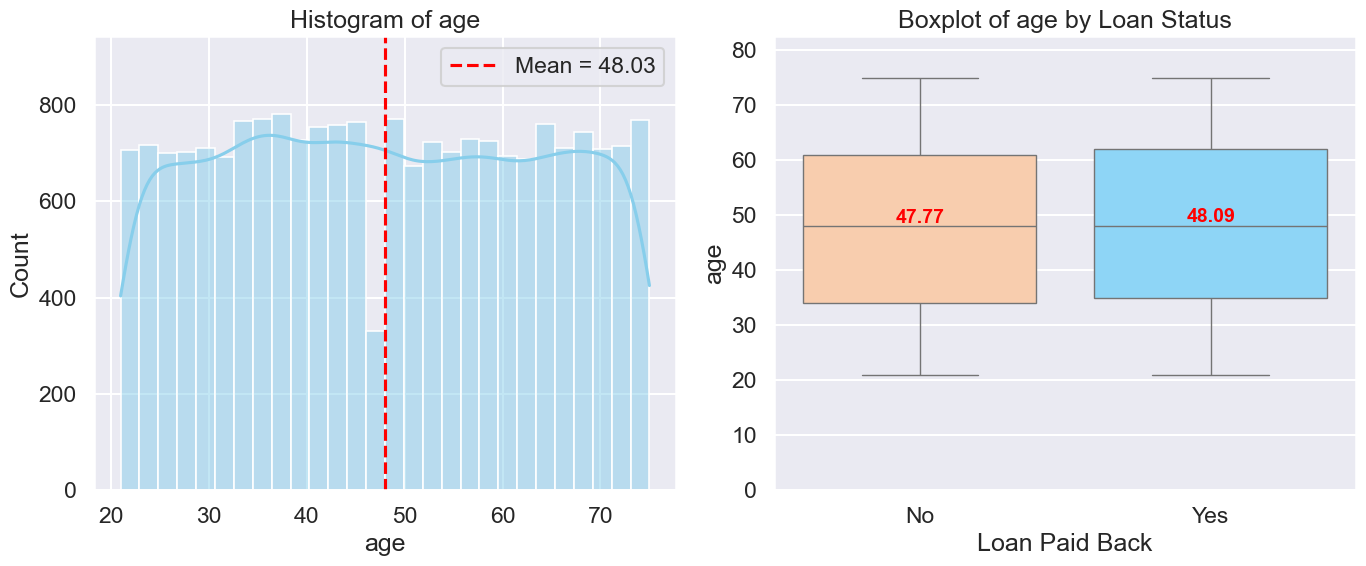

In [280]:
# Analyze 'age' column
statistical_summary_for_numerical('age')
plot_numerical_distribution('age')

##### 🔍 **Age** — Analysis Summary

- **Distribution** : Roughly uniform across ages 21–75, nearly perfect symmetry (skew = 0.01, Mean ≈ Median ≈ 48)
- **Spread** : Wide range (std = 15.83), age is well distributed across the dataset
- **vs Loan Status** : Mean age is almost identical between groups (47.77 vs 48.09), a difference of only 0.32
- **Statistical Test** : T-test p = 0.258 ❌ — difference between groups is not statistically significant
- **Correlation** : Point-biserial r = 0.008 — near-zero, confirms no linear relationship with loan repayment
- **Conclusion** : `age` has **no meaningful relationship** with loan repayment — not expected to be a useful predictor

#### 2. Distribution of Gender


──────────────────────────────────────────────────
📊 Summary for 'gender'
──────────────────────────────────────────────────
Total Unique Values : 3
──────────────────────────────────────────────────
Value Distribution:
  Female          Count: 10034    (50.17%)
  Male            Count: 9536     (47.68%)
  Other           Count: 430      (2.15%)
──────────────────────────────────────────────────
Distribution by Loan Status (%):

  Loan Status         Female         Male           Other          
  ·································································
  Not Paid (0)        49.53%        48.25%        2.22%        
  Paid     (1)        50.33%        47.54%        2.13%        
──────────────────────────────────────────────────
Chi-squared : 0.8836
p-value     : 0.6429  ❌ Not significant
Degrees of Freedom : 2
──────────────────────────────────────────────────



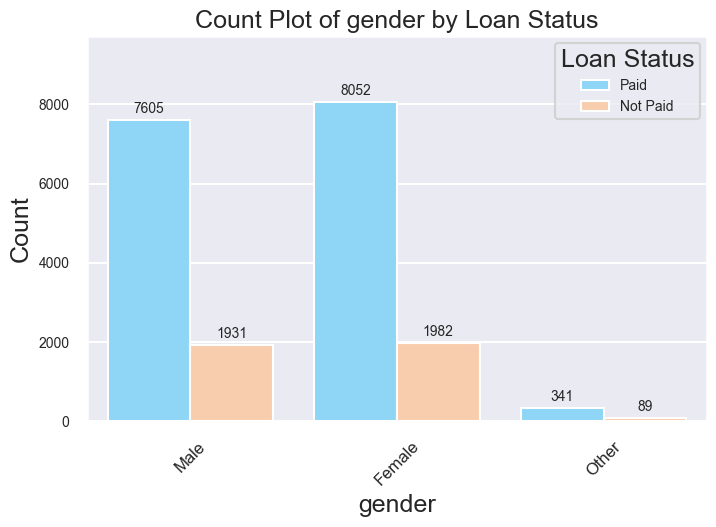

In [283]:
statistical_summary_for_categorical('gender')
plot_categorical_distribution('gender')

##### 🔍 **Gender** — Analysis Summary

- **Distribution** : Slightly female-dominated (50.17%), followed by Male (47.68%), with a small Other group (2.15%)
- **vs Loan Status** : Repayment rates are nearly identical across all genders — Paid rate: Female 50.33%, Male 47.54%, Other 2.13%
- **Statistical Test** : Chi-squared p = 0.643 ❌ — no statistically significant association between gender and loan repayment
- **Conclusion** : `gender` has **no meaningful relationship** with loan repayment — unlikely to contribute predictive power